In [199]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [200]:
df = pd.read_csv('house-votes-84.csv' )

In [201]:
print('dataset shape:', df.shape)
print('dataset columns:', df.columns.to_list() )

dataset shape: (435, 17)
dataset columns: ['Class Name', ' handicapped-infants', ' water-project-cost-sharing', ' adoption-of-the-budget-resolution', ' physician-fee-freeze', ' el-salvador-aid', ' religious-groups-in-schools', ' anti-satellite-test-ban', ' aid-to-nicaraguan-contras', ' mx-missile', ' immigration', ' synfuels-corporation-cutback', ' education-spending', ' superfund-right-to-sue', ' crime', ' duty-free-exports', ' export-administration-act-south-africa']


In [202]:
class_counts = df['Class Name'].value_counts()
class_percents = df['Class Name'].value_counts(normalize=True)*100

print(class_counts)
print(f"Democrat : {class_percents['democrat']:.2f}%")
print(f"Republican : {class_percents['republican']:.2f}%")

Class Name
democrat      267
republican    168
Name: count, dtype: int64
Democrat : 61.38%
Republican : 38.62%


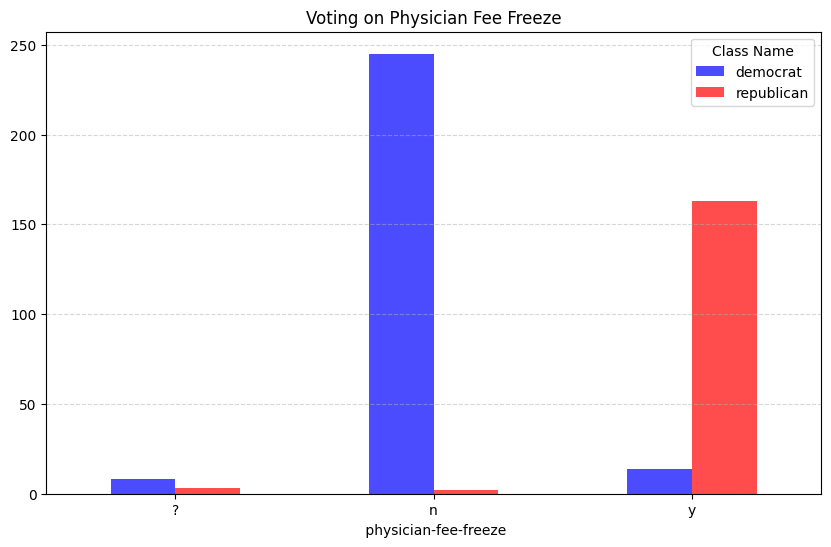

In [203]:
cross_tab = pd.crosstab(df[' physician-fee-freeze'], df['Class Name'])

ax = cross_tab.plot(kind='bar', figsize=(10, 6), color=['blue', 'red'], alpha=0.7)
plt.title('Voting on Physician Fee Freeze')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [204]:
df.columns = df.columns.str.strip()

for col in df.columns:
    if df[col].dtype == object:
        df[col] = df[col].str.strip()

df.replace('?', 'abstain', inplace=True)
target_col = 'Class Name' 
pos_label = 'democrat'

In [205]:
def train_test_split(df, target_col='Class Name', test_size=0.15, valid_size=0.15):

    shuffled_df = df.sample(frac=1, random_state=42).reset_index(drop=True)
    
    train_list = []
    val_list = []
    test_list = []
    
    grouped = shuffled_df.groupby(target_col)

    for name, group in grouped:
        n_test = int(len(group) * test_size)
        n_val = int(len(group) * valid_size)
        
        test_part = group.iloc[:n_test]
        val_part = group.iloc[n_test:(n_test + n_val)]
        train_part = group.iloc[(n_test + n_val):]
        
        test_list.append(test_part)
        val_list.append(val_part)
        train_list.append(train_part)
    
        train_set = pd.concat(train_list).sample(frac=1, random_state=42).reset_index(drop=True)
        test_set = pd.concat(test_list).sample(frac=1, random_state=42).reset_index(drop=True)
        val_set = pd.concat(val_list).sample(frac=1, random_state=42).reset_index(drop=True)


    return train_set, val_set, test_set

In [206]:
train_df, val_df, test_df = train_test_split(df, 'Class Name', test_size=0.15, valid_size=0.15)

In [207]:
def calculate_f1(y_true, y_pred, pos_label):

    tp = sum((yt == pos_label and yp == pos_label) for yt, yp in zip(y_true, y_pred))
    fp = sum((yt != pos_label and yp == pos_label) for yt, yp in zip(y_true, y_pred))
    fn = sum((yt == pos_label and yp != pos_label) for yt, yp in zip(y_true, y_pred))
    
    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    F1 = 2 * (precision * recall) / (precision + recall + 1e-9)
    return F1

ID3

In [208]:
def calculate_entropy(series):
    probs = series.value_counts(normalize=True)
    # - sigma p * log2(p)
    entropy = -np.sum(probs * np.log2(probs + 1e-9))
    return entropy


def calculate_gini(series):
    probs = series.value_counts(normalize=True)
    gini = 1 - np.sum(probs ** 2)
    return gini

def calculate_split_info(df, feature):
    total_rows = len(df)
    split_info = 0
    for val, subset in df.groupby(feature):
        weight = len(subset) / total_rows
        split_info -= weight * np.log2(weight + 1e-9)
    return split_info

def calculate_split_metric(df, feature, target_col, criterion):
    total_rows = len(df)

    if criterion == 'gini':
        parent_metric = calculate_gini(df[target_col])
    else:
        parent_metric = calculate_entropy(df[target_col])
        
    weighted_child_metric = 0
    
    for val, subset in df.groupby(feature):
        weight = len(subset) / total_rows
        if criterion == 'gini':
            weighted_child_metric += weight * calculate_gini(subset[target_col])
        else:
            weighted_child_metric += weight * calculate_entropy(subset[target_col])
            
    gain = parent_metric - weighted_child_metric
    
    if criterion == 'gain_ratio':
        split_info = calculate_split_info(df, feature)
        return gain / (split_info + 1e-9)
    else:
        return gain

In [ ]:
def id3(df, features, target, criterion='entropy', max_depth=float('inf'), min_samples=2, depth=0):
    unique_classes = df[target].unique()
    mode_class = df[target].mode()[0]
    count = len(df)
    
    leaf = {'class': mode_class, 'count': count, 'type': 'leaf'}
    
    if len(unique_classes) == 1:
        return {'class': unique_classes[0], 'count': count, 'type': 'leaf'}
    
    if len(features) == 0 or len(df) < min_samples or depth >= max_depth:
        return leaf

    gains = {f: calculate_split_metric(df, f, target, criterion) for f in features}
    best_feature = max(gains, key=gains.get)
    
    if gains[best_feature] <= 0:
        return leaf
    
    tree = {best_feature: {}}
    remaining_features = [f for f in features if f != best_feature]
    
    for val, subset in df.groupby(best_feature):
        tree[best_feature][val] = id3(subset, remaining_features, target, criterion, max_depth, min_samples, depth+1)
        
    tree[best_feature]['__default__'] = leaf
    return tree


def predict_tree(tree, row, default_class):
    if isinstance(tree, dict) and tree.get('type') == 'leaf':
        return tree['class']
    
    if not isinstance(tree, dict):
        return default_class
    
    feature = list(tree.keys())[0]
    val = row.get(feature, None)

    if val in tree[feature]:
        return predict_tree(tree[feature][val], row, default_class)
    
    default_node = tree[feature].get('__default__', default_class)

    if isinstance(default_node, dict) and default_node.get('type') == 'leaf':
        return default_node['class']
    
    return default_class

PRISM

In [ ]:
def prism(df, target_col='Class Name'):
    rules = []
    classes = df[target_col].unique()
    
    for target_class in classes:
        current_df = df.copy()
        while len(current_df[current_df[target_col] == target_class]) > 0:
            rule = []
            subset = current_df.copy()
            while True:
                if len(subset[subset[target_col] != target_class]) == 0: break
                
                best_acc = -1
                best_feat = None
                best_val = None
                available_features = [c for c in subset.columns if c != target_col]
                
                for feat in available_features:
                    if feat in [r[0] for r in rule]: continue
                    for val in subset[feat].unique():
                        temp_subset = subset[subset[feat] == val]
                        if len(temp_subset) == 0: continue
                        target_count = len(temp_subset[temp_subset[target_col] == target_class])
                        acc = target_count / len(temp_subset)
                        
                        if acc > best_acc:
                            best_acc = acc
                            best_feat = feat
                            best_val = val
                        elif acc == best_acc and acc > -1:
                            if len(temp_subset) > len(subset[subset.get(best_feat) == best_val]):
                                best_feat = feat
                                best_val = val
                
                if best_feat is None: break
                rule.append((best_feat, best_val))
                subset = subset[subset[best_feat] == best_val]

            full_mask = np.ones(len(df), dtype=bool)
            rule_str = "IF "
            for f, v in rule:
                full_mask &= (df[f] == v)
                rule_str += f"({f}={v}) AND "
            
            matched_rows = df[full_mask]
            coverage = len(matched_rows)
            errors = len(matched_rows[matched_rows[target_col] != target_class])
            
            rules.append({
                'target': target_class, 
                'rule': rule,
                'rule_string': rule_str[:-5],
                'coverage': coverage,
                'errors': errors
            })
            
            indices_to_drop = subset.index
            current_df = current_df.drop(indices_to_drop)
    return rules

Grid Search - 48 cases

In [211]:
depths = [3, 5, 9, 11]
min_samples = [2, 10, 20, 30]
criteria = ['entropy', 'gain_ratio', 'gini']
results = []
best_configs = {}

features = [c for c in df.columns if c != 'Class Name']
default_mode = train_df['Class Name'].mode()[0]

for crit in criteria:
    best_f1_for_crit = -1
    best_params_for_crit = None
    
    for d in depths:
        for s in min_samples:
            tree = id3(train_df, features, 'Class Name', crit, d, s)
            
            preds = val_df.apply(lambda row: predict_tree(tree, row, default_mode), axis=1)
            f1 = calculate_f1(val_df['Class Name'], preds, pos_label)
            
            results.append({'Criterion': crit, 'Max Depth': d, 'Min Samples': s, 'F1 Score': f1})
            
            if f1 > best_f1_for_crit:
                best_f1_for_crit = f1
                best_params_for_crit = (d, s)
    
    best_configs[crit] = best_params_for_crit

results_df = pd.DataFrame(results)
results_df.to_csv('grid_search_results.csv', index=False)
print("Results saved to CSV.")

Results saved to CSV.


In [212]:
full_train = pd.concat([train_df, val_df])
final_results = []
best_tree_viz = None
best_overall_f1 = -1

for crit, params in best_configs.items():
    d, s = params
    tree = id3(full_train, features, 'Class Name', crit, d, s)
    preds = test_df.apply(lambda row: predict_tree(tree, row, default_mode), axis=1)
    test_f1 = calculate_f1(test_df['Class Name'], preds, pos_label)
    
    print(f"Method: {crit}, Params: {params}, Test F1: {test_f1:.4f}")
    
    if test_f1 > best_overall_f1:
        best_overall_f1 = test_f1
        best_tree_viz = tree

Method: entropy, Params: (3, 2), Test F1: 0.9286
Method: gain_ratio, Params: (9, 2), Test F1: 0.9398
Method: gini, Params: (3, 2), Test F1: 0.9286


In [213]:
prism_rules = prism(train_df)
prism_df = pd.DataFrame(prism_rules).sort_values(by='coverage', ascending=False)
prism_df.to_csv('prism_rules_final.csv', index=False)
print("Results saved to CSV.")

Results saved to CSV.


In [214]:
def print_tree(tree, indent=""):
    if isinstance(tree, dict) and tree.get('type') == 'leaf':
        print(f"{indent}➔ Class: {tree['class']} (Count: {tree['count']})")
        return

    feature = list(tree.keys())[0]
    print(f"{indent}[{feature} ?]")

    branches = tree[feature]
    for value, subtree in branches.items():
        if value == '__default__': continue
        print(f"{indent}  ├── If {value}:")
        print_tree(subtree, indent + "  │   ")


print_tree(best_tree_viz)


[physician-fee-freeze ?]
  ├── If abstain:
  │   [mx-missile ?]
  │     ├── If abstain:
  │     │   ➔ Class: republican (Count: 2)
  │     ├── If n:
  │     │   ➔ Class: democrat (Count: 4)
  │     ├── If y:
  │     │   ➔ Class: democrat (Count: 2)
  ├── If n:
  │   [adoption-of-the-budget-resolution ?]
  │     ├── If abstain:
  │     │   ➔ Class: democrat (Count: 2)
  │     ├── If n:
  │     │   [education-spending ?]
  │     │     ├── If abstain:
  │     │     │   ➔ Class: republican (Count: 1)
  │     │     ├── If n:
  │     │     │   [synfuels-corporation-cutback ?]
  │     │     │     ├── If n:
  │     │     │     │   [religious-groups-in-schools ?]
  │     │     │     │     ├── If n:
  │     │     │     │     │   [crime ?]
  │     │     │     │     │     ├── If n:
  │     │     │     │     │     │   ➔ Class: democrat (Count: 1)
  │     │     │     │     │     ├── If y:
  │     │     │     │     │     │   ➔ Class: republican (Count: 1)
  │     │     │     │     ├── If y:
  │     │